In [1]:
from bengrn import BenGRN
import scanpy as sc
from bengrn.base import train_classifier

from anndata.utils import make_index_unique
from grnndata import utils as grnutils
from grnndata import read_h5ad

from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
import seaborn as sns
import plotly.express as px

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

from scdataloader import utils as data_utils
import numpy as np

from pyvis import network as pnx
import networkx as nx
import scipy.sparse
import pandas as pd
import gseapy as gp
from gseapy import dotplot

%load_ext autoreload
%autoreload 2 

/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


→ connected lamindb: anonymous/test


In [ ]:
# load the generated gene networks from the previous notebook
grn_adult = read_h5ad("1_scPRINT/data/grn_sc_adult.h5ad")
# Remove duplicates and process gene symbols
grn_adult.var.symbol = make_index_unique(grn_adult.var.symbol.astype(str))

# Convert gene ids to symbols for better readability
grn_adult.var['ensembl_id'] = grn_adult.var.index
grn_adult.var.index = grn_adult.var.symbol

# Additional step: Remove any remaining duplicates after index assignment
if grn_adult.var.index.duplicated().any():
    print(f"Found {grn_adult.var.index.duplicated().sum()} duplicate entries after index assignment")
    grn_adult = grn_adult[:, ~grn_adult.var.index.duplicated(keep='first')]
    print("Removed duplicate entries")

print(f"GRN shape: {grn_adult.shape}")
print(f"Number of genes: {grn_adult.n_vars}")
print(f"Number of cells/observations: {grn_adult.n_obs}")

GRN shape: (1030, 3000)
Number of genes: 3000
Number of cells/observations: 1030


In [3]:
grnutils.get_centrality(grn_adult, 20, top_k_to_disp=0)
grn_adult = grnutils.compute_cluster(grn_adult, resolution=1.5, use="leiden", n_iterations=10, max_comm_size=200)

Top central genes: []


In [ ]:
# load the generated gene networks from the previous notebook
grn_fetal = read_h5ad("1_scPRINT/data/grn_sc_fetal.h5ad")
# Remove duplicates and process gene symbols
grn_fetal.var.symbol = make_index_unique(grn_fetal.var.symbol.astype(str))

# Convert gene ids to symbols for better readability
grn_fetal.var['ensembl_id'] = grn_fetal.var.index
grn_fetal.var.index = grn_fetal.var.symbol

# Additional step: Remove any remaining duplicates after index assignment
if grn_fetal.var.index.duplicated().any():
    print(f"Found {grn_fetal.var.index.duplicated().sum()} duplicate entries after index assignment")
    grn_fetal = grn_fetal[:, ~grn_fetal.var.index.duplicated(keep='first')]
    print("Removed duplicate entries")

print(f"GRN shape: {grn_fetal.shape}")
print(f"Number of genes: {grn_fetal.n_vars}")
print(f"Number of cells/observations: {grn_fetal.n_obs}")

GRN shape: (7305, 3000)
Number of genes: 3000
Number of cells/observations: 7305


In [5]:
grnutils.get_centrality(grn_fetal, 20, top_k_to_disp=0)
grn_fetal = grnutils.compute_cluster(grn_fetal, resolution=1.5, use="leiden", n_iterations=10, max_comm_size=200)

Top central genes: []


In [6]:
common = set(grn_fetal.var.symbol) & set(grn_adult.var.symbol)
len(common)

1437

In [7]:
grn_fetal.var.centrality.sort_values(ascending=False).head(10)

symbol
RPL26L1    0.269750
EIF5AL1    0.268328
TAMM41     0.266374
ALG6       0.264062
MRPL36     0.256255
SENP6      0.241618
MRPS11     0.239160
BPTF       0.227616
POLR1B     0.226165
TSPAN8     0.219002
Name: centrality, dtype: float64

In [8]:
grn_adult.var.centrality.sort_values(ascending=False).head(10)

symbol
ATP5MC1    0.288497
SENP6      0.281725
NDUFB3     0.278304
HMGA1      0.276837
MRPL15     0.244644
MT-ND6     0.234026
CAMK2A     0.217194
GSTT1      0.216860
BTBD18     0.211158
MT-CO1     0.207338
Name: centrality, dtype: float64

In [9]:
grn_fetal.var['cluster_1.5']

symbol
TSPAN6     3
DPM1       4
FUCA2      1
CFTR       5
LAP3       7
          ..
SCO2      13
nan-1      4
PRRC2B     4
HOMEZ      4
SOD2      13
Name: cluster_1.5, Length: 3000, dtype: category
Categories (40, object): ['0', '1', '2', '3', ..., '36', '37', '38', '39']

In [10]:
grn_adult.var['cluster_1.5']

symbol
TSPAN6     9
DPM1       0
FIRRM      0
FUCA2      3
CFTR      12
          ..
nan-3      0
LRTOMT    12
nan-4     11
nan-5      8
SOD2      15
Name: cluster_1.5, Length: 3000, dtype: category
Categories (32, object): ['0', '1', '2', '3', ..., '28', '29', '30', '31']

In [11]:
df = grn_adult.var['cluster_1.5']

In [12]:
df.to_csv('cluster_1.5.csv')

## Venn diagrams

In [13]:
# Import libraries for Venn diagrams
from matplotlib_venn import venn2, venn2_circles
import itertools

In [14]:
# First, let's examine the cluster assignments
print("Fetal GRN clusters:")
print(f"Number of unique clusters: {grn_fetal.var['cluster_1.5'].nunique()}")
print("Cluster distribution:")
print(grn_fetal.var['cluster_1.5'].value_counts().sort_index())

print("\nAdult GRN clusters:")
print(f"Number of unique clusters: {grn_adult.var['cluster_1.5'].nunique()}")
print("Cluster distribution:")
print(grn_adult.var['cluster_1.5'].value_counts().sort_index())

Fetal GRN clusters:
Number of unique clusters: 40
Cluster distribution:
cluster_1.5
0     200
1     200
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
11    200
12    165
13    152
14    146
15     76
16     18
17     10
18      5
19      4
20      3
21      3
22      1
23      1
24      1
25      1
26      1
27      1
28      1
29      1
30      1
31      1
32      1
33      1
34      1
35      1
36      1
37      1
38      1
39      1
Name: count, dtype: int64

Adult GRN clusters:
Number of unique clusters: 32
Cluster distribution:
cluster_1.5
0     200
1     200
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
11    200
12    155
13    150
14    124
15     90
16     61
17      5
18      2
19      1
20      1
21      1
22      1
23      1
24      1
25      1
26      1
27      1
28      1
29      1
30      1
31      1
Name: count, dtype: int64


In [15]:
# Function to calculate Jaccard similarity between two gene sets
def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity between two sets"""
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Function to get genes in a specific cluster
def get_cluster_genes(grn_data, cluster_id):
    """Get gene symbols for a specific cluster"""
    cluster_mask = grn_data.var['cluster_1.5'] == cluster_id
    return set(grn_data.var.index[cluster_mask].tolist())

In [16]:
# Get unique cluster IDs for both datasets
fetal_clusters = sorted(grn_fetal.var['cluster_1.5'].unique())
adult_clusters = sorted(grn_adult.var['cluster_1.5'].unique())

print(f"All fetal clusters: {fetal_clusters}")
print(f"All adult clusters: {adult_clusters}")

# Filter clusters with at least 30 genes
min_genes = 30
filtered_fetal_clusters = []
filtered_adult_clusters = []

print(f"\nFiltering clusters with at least {min_genes} genes:")
for cluster in fetal_clusters:
    cluster_genes = get_cluster_genes(grn_fetal, cluster)
    if len(cluster_genes) >= min_genes:
        filtered_fetal_clusters.append(cluster)

for cluster in adult_clusters:
    cluster_genes = get_cluster_genes(grn_adult, cluster)
    if len(cluster_genes) >= min_genes:
        filtered_adult_clusters.append(cluster)

print(f"\nFiltered fetal clusters: {filtered_fetal_clusters}")
print(f"Filtered adult clusters: {filtered_adult_clusters}")

# Calculate Jaccard similarity between all pairs of filtered clusters
similarity_matrix = []
cluster_pairs = []

for fetal_cluster in filtered_fetal_clusters:
    for adult_cluster in filtered_adult_clusters:
        fetal_genes = get_cluster_genes(grn_fetal, fetal_cluster)
        adult_genes = get_cluster_genes(grn_adult, adult_cluster)
        
        similarity = jaccard_similarity(fetal_genes, adult_genes)
        similarity_matrix.append(similarity)
        cluster_pairs.append((fetal_cluster, adult_cluster))
        
        print(f"Fetal cluster {fetal_cluster} vs Adult cluster {adult_cluster}: "
              f"Jaccard similarity = {similarity:.4f}")

# Convert to DataFrame for easier analysis
similarity_df = pd.DataFrame({
    'fetal_cluster': [pair[0] for pair in cluster_pairs],
    'adult_cluster': [pair[1] for pair in cluster_pairs],
    'jaccard_similarity': similarity_matrix
})

# Find the most similar pair
max_similarity_idx = similarity_df['jaccard_similarity'].idxmax()
best_match = similarity_df.iloc[max_similarity_idx]

print(f"\nMost similar pair (after filtering):")
print(f"Fetal cluster {best_match['fetal_cluster']} and Adult cluster {best_match['adult_cluster']}")
print(f"Jaccard similarity: {best_match['jaccard_similarity']:.4f}")

All fetal clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '5', '6', '7', '8', '9']
All adult clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '4', '5', '6', '7', '8', '9']

Filtering clusters with at least 30 genes:

Filtered fetal clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5', '6', '7', '8', '9']
Filtered adult clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9']
Fetal cluster 0 vs Adult cluster 0: Jaccard similarity = 0.0076
Fetal cluster 0 vs Adult cluster 1: Jaccard similarity = 0.0127
Fetal cluster 0 vs Adult cluster 10: Jaccard similarity = 0.0178
Fetal cluster 0 vs Adult cluster 11: Jaccard similarity = 0.0076
Fetal cluster

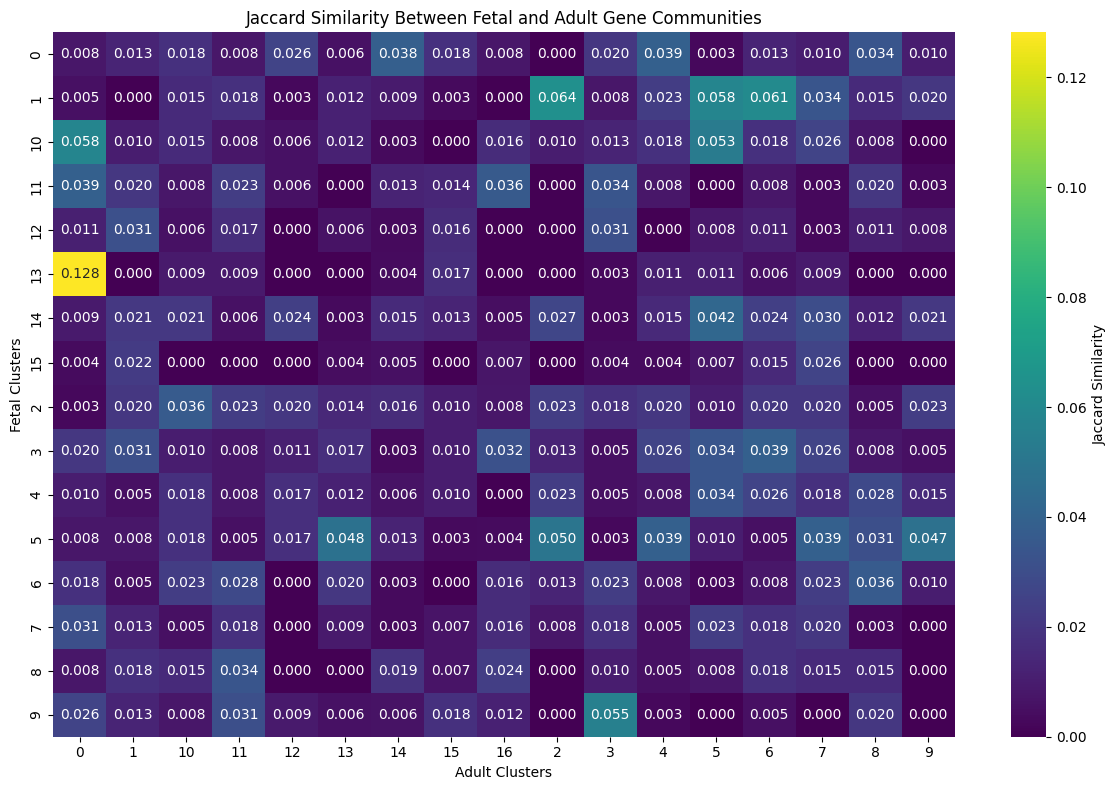

In [17]:
# Create a heatmap of similarities
similarity_pivot = similarity_df.pivot(index='fetal_cluster', columns='adult_cluster', values='jaccard_similarity')

plt.figure(figsize=(12, 8))
sns.heatmap(similarity_pivot, annot=True, cmap='viridis', fmt='.3f', 
            cbar_kws={'label': 'Jaccard Similarity'})
plt.title('Jaccard Similarity Between Fetal and Adult Gene Communities')
plt.xlabel('Adult Clusters')
plt.ylabel('Fetal Clusters')
plt.tight_layout()
plt.show()

Top 9 Most Similar Community Pairs:
86. Fetal cluster 13 vs Adult cluster 0 (Jaccard similarity: 0.1282)
27. Fetal cluster 1 vs Adult cluster 2 (Jaccard similarity: 0.0638)
31. Fetal cluster 1 vs Adult cluster 6 (Jaccard similarity: 0.0610)
30. Fetal cluster 1 vs Adult cluster 5 (Jaccard similarity: 0.0582)
35. Fetal cluster 10 vs Adult cluster 0 (Jaccard similarity: 0.0582)
266. Fetal cluster 9 vs Adult cluster 3 (Jaccard similarity: 0.0554)
47. Fetal cluster 10 vs Adult cluster 5 (Jaccard similarity: 0.0526)
197. Fetal cluster 5 vs Adult cluster 2 (Jaccard similarity: 0.0499)
193. Fetal cluster 5 vs Adult cluster 13 (Jaccard similarity: 0.0479)


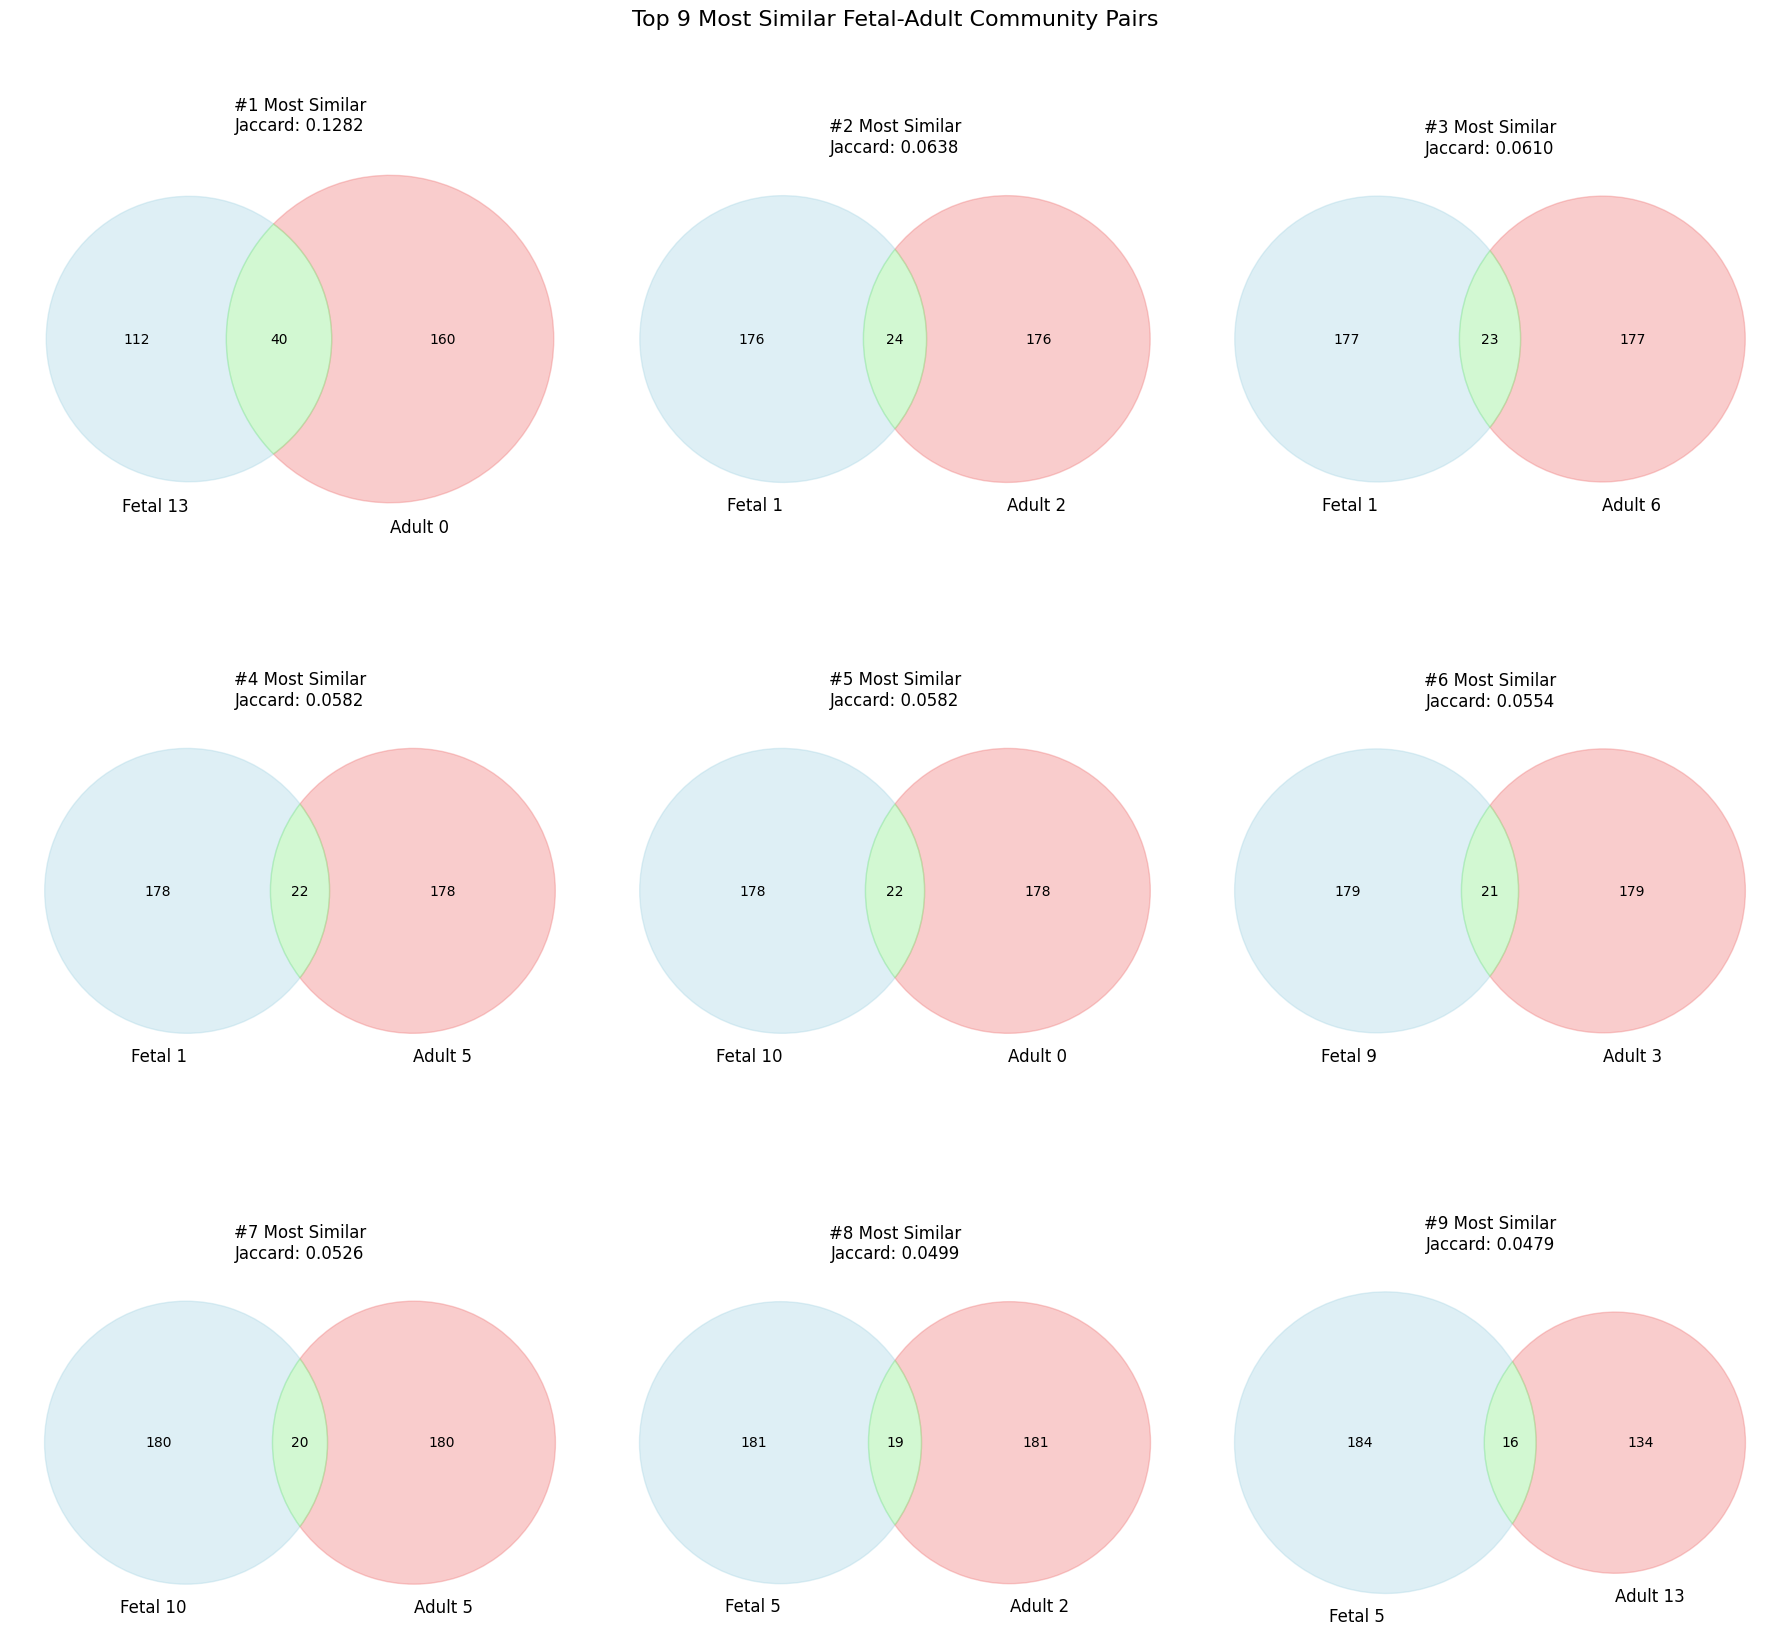

In [18]:
# Let's also look at the top 9 most similar pairs
top_9_matches = similarity_df.nlargest(9, 'jaccard_similarity')

print("Top 9 Most Similar Community Pairs:")
for i, row in top_9_matches.iterrows():
    print(f"{row.name + 1}. Fetal cluster {row['fetal_cluster']} vs Adult cluster {row['adult_cluster']} "
          f"(Jaccard similarity: {row['jaccard_similarity']:.4f})")

# Create subplots for top 9 matches (3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, (_, row) in enumerate(top_9_matches.iterrows()):
    fetal_cluster = row['fetal_cluster']
    adult_cluster = row['adult_cluster']
    similarity = row['jaccard_similarity']
    
    fetal_genes = get_cluster_genes(grn_fetal, fetal_cluster)
    adult_genes = get_cluster_genes(grn_adult, adult_cluster)
    
    ax = axes[idx]
    plt.sca(ax)
    
    venn = venn2([fetal_genes, adult_genes], 
                 set_labels=[f'Fetal {fetal_cluster}', f'Adult {adult_cluster}'],
                 ax=ax)
    
    # Customize colors
    if venn.get_patch_by_id('10'):
        venn.get_patch_by_id('10').set_color('lightblue')
    if venn.get_patch_by_id('01'):
        venn.get_patch_by_id('01').set_color('lightcoral')
    if venn.get_patch_by_id('11'):
        venn.get_patch_by_id('11').set_color('lightgreen')
    
    ax.set_title(f'#{idx + 1} Most Similar\nJaccard: {similarity:.4f}')

plt.suptitle('Top 9 Most Similar Fetal-Adult Community Pairs', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## Visualize changes in centrality degree

In [19]:
# Define the community pairs you want to compare manually
# Format: [(fetal_cluster, adult_cluster), (fetal_cluster, adult_cluster), ...]
community_pairs_to_compare = [
    ('13', '0'),  # Fetal cluster 13 vs Adult cluster 0
]
TOP = 100
grnutils.get_centrality(grn_fetal, TOP, top_k_to_disp=0)
grnutils.get_centrality(grn_adult, TOP, top_k_to_disp=0)

Top central genes: []
Top central genes: []


[]

In [20]:
# Create bubble data for manually selected community pairs
bubble_data = []

for idx, (fetal_cluster, adult_cluster) in enumerate(community_pairs_to_compare):
    
    # Get Jaccard similarity for this pair
    mask = (similarity_df['fetal_cluster'] == fetal_cluster) & (similarity_df['adult_cluster'] == adult_cluster)
    if mask.any():
        similarity = similarity_df[mask]['jaccard_similarity'].iloc[0]
        print(f"  Jaccard similarity: {similarity:.4f}")
    
    # Get genes for both clusters
    fetal_genes = get_cluster_genes(grn_fetal, fetal_cluster)
    adult_genes = get_cluster_genes(grn_adult, adult_cluster)
    
    # Find common genes
    common_genes = fetal_genes.intersection(adult_genes)
    
    # For each common gene, get centrality scores
    for gene in common_genes:
        if gene in grn_fetal.var.index and gene in grn_adult.var.index:
            fetal_centrality = grn_fetal.var.loc[gene, 'centrality']
            adult_centrality = grn_adult.var.loc[gene, 'centrality']
            
            # Calculate absolute difference in centrality
            centrality_diff = abs(adult_centrality - fetal_centrality)
            
            bubble_data.append({
                'gene': gene,
                'community_pair': f'F{fetal_cluster} vs A{adult_cluster}',
                'fetal_cluster': fetal_cluster,
                'adult_cluster': adult_cluster,
                'fetal_centrality': fetal_centrality,
                'adult_centrality': adult_centrality,
                'centrality_difference': centrality_diff,
                'centrality_change': adult_centrality - fetal_centrality,
                'jaccard_similarity': similarity
            })

# Create DataFrame
bubble_df = pd.DataFrame(bubble_data)
bubble_df

  Jaccard similarity: 0.1282


,gene,community_pair,fetal_cluster,adult_cluster,fetal_centrality,adult_centrality,centrality_difference,centrality_change,jaccard_similarity
0,RPS6,F13 vs A0,13,0,6.168705e-02,8.539012e-02,2.370307e-02,2.370307e-02,0.128205
1,RPL31,F13 vs A0,13,0,3.928544e-02,1.049110e-02,2.879434e-02,-2.879434e-02,0.128205
2,RPS24,F13 vs A0,13,0,9.516556e-02,4.145770e-02,5.370786e-02,-5.370786e-02,0.128205
3,RPS12,F13 vs A0,13,0,9.148162e-02,5.848828e-02,3.299334e-02,-3.299334e-02,0.128205
4,MT-ATP8,F13 vs A0,13,0,5.304945e-02,1.418616e-01,8.881213e-02,8.881213e-02,0.128205
5,COX7C,F13 vs A0,13,0,5.141828e-19,1.728371e-02,1.728371e-02,1.728371e-02,0.128205
6,MT-CYB,F13 vs A0,13,0,9.415488e-03,1.468203e-01,1.374048e-01,1.374048e-01,0.128205
7,MT-ND4,F13 vs A0,13,0,7.730212e-03,1.051260e-01,9.739582e-02,9.739582e-02,0.128205
8,MT-ND2,F13 vs A0,13,0,1.781712e-03,7.714126e-02,7.535954e-02,7.535954e-02,0.128205
9,EGR1,F13 vs A0,13,0,1.902476e-17,1.777291e-15,1.758267e-15,1.758267e-15,0.128205


In [21]:
fig1 = px.scatter(bubble_df, 
                x='fetal_centrality', 
                y='adult_centrality',
                size='centrality_difference',
                color='centrality_change',
                hover_data=['gene'],
                title=f'Centrality Changes: {bubble_df["community_pair"].iloc[0]}<br>Bubble size = Centrality difference',
                labels={
                    'fetal_centrality': 'Fetal Centrality Score',
                    'adult_centrality': 'Adult Centrality Score',
                    'centrality_difference': 'Centrality Difference (|Adult - Fetal|)',
                    'centrality_change': 'Centrality Change (Adult - Fetal)'
                },
                color_continuous_scale='RdBu_r',
                size_max=30)

# Add diagonal line (y=x) to show where centrality would be equal
min_val = min(bubble_df['fetal_centrality'].min(), bubble_df['adult_centrality'].min())
max_val = max(bubble_df['fetal_centrality'].max(), bubble_df['adult_centrality'].max())

fig1.add_shape(type='line',
                x0=min_val, y0=min_val,
                x1=max_val, y1=max_val,
                line=dict(color='gray', dash='dash'),
                name='Equal centrality line')

fig1.update_layout(width=800, height=600, showlegend=True)
fig1.show()

## Find communities with same centrality node

In [22]:
def get_top_central_nodes(grn_data, cluster_id, top_k=10):
    """Get top k central nodes for a specific cluster"""
    cluster_mask = grn_data.var['cluster_1.5'] == cluster_id
    cluster_genes = grn_data.var.index[cluster_mask]
    
    # Get centrality scores for genes in this cluster
    cluster_centrality = grn_data.var.loc[cluster_genes, 'centrality']
    
    # Return top k central genes
    top_central = cluster_centrality.nlargest(top_k)
    return set(top_central.index)

In [23]:
def central_node_similarity(fetal_central, adult_central):
    """Calculate similarity based on overlap of central nodes"""
    intersection = len(fetal_central.intersection(adult_central))
    union = len(fetal_central.union(adult_central))
    return intersection / union if union > 0 else 0

In [24]:
# Parameters for central node analysis
top_k_central = 20  # Number of top central nodes to consider

# Calculate central node similarities for all filtered cluster pairs
central_similarity_data = []

for fetal_cluster in filtered_fetal_clusters:
    for adult_cluster in filtered_adult_clusters:
        # Get top central nodes for each cluster
        fetal_central = get_top_central_nodes(grn_fetal, fetal_cluster, top_k_central)
        adult_central = get_top_central_nodes(grn_adult, adult_cluster, top_k_central)
        
        # Calculate central node similarity
        central_sim = central_node_similarity(fetal_central, adult_central)
        
        # Get corresponding gene overlap similarity
        mask = (similarity_df['fetal_cluster'] == fetal_cluster) & (similarity_df['adult_cluster'] == adult_cluster)
        gene_jaccard_sim = similarity_df[mask]['jaccard_similarity'].iloc[0]
        
        # Count overlapping central nodes
        common_central = fetal_central.intersection(adult_central)
        
        central_similarity_data.append({
            'fetal_cluster': fetal_cluster,
            'adult_cluster': adult_cluster,
            'central_node_similarity': central_sim,
            'gene_jaccard_similarity': gene_jaccard_sim,
            'overlapping_central_nodes': len(common_central),
            'fetal_central_nodes': list(fetal_central),
            'adult_central_nodes': list(adult_central),
            'common_central_nodes': list(common_central)
        })

In [25]:
central_df = pd.DataFrame(central_similarity_data)
central_similarity_df = central_df.sort_values('central_node_similarity', ascending=False)
central_similarity_df

,fetal_cluster,adult_cluster,central_node_similarity,gene_jaccard_similarity,overlapping_central_nodes,fetal_central_nodes,adult_central_nodes,common_central_nodes
85,13,0,0.081081,0.128205,3,"[RPS24, RPL37, RPS12, RPS23, RPL32, RPL18, RPL...","[nan-3, DACH1, RPS6, RPS12, MT-ATP8, MT-CYB, M...","[RPL8, RPS12, RPL36]"
161,3,16,0.052632,0.031621,2,"[EIF4B, NCL, TBCA, HNRNPK, HMGCS2, HMGA1, PCYT...","[MDH2, NOP16, TMEM200B, TOMM22, PAICS, TIMM13,...","[COX4I1, PCYT2]"
149,2,6,0.052632,0.020408,2,"[IGF2BP1, CCDC47, FOXA2, DBNDD1, PRKDC, CLINT1...","[IRF2BP2, PRKDC, EAPP, DNAJC17, AVPI1, DCTN4, ...","[CNOT2, PRKDC]"
43,10,2,0.025641,0.010101,1,"[CLDN3, PNISR, SCAF11, PDIA3, NASP, XRCC5, EPC...","[DSTN, NFIB, ETV6, GLUL, LOXL3, RGS12, CTBP2, ...",[GSTP1]
166,3,6,0.025641,0.038961,1,"[EIF4B, NCL, TBCA, HNRNPK, HMGCS2, HMGA1, PCYT...","[IRF2BP2, PRKDC, EAPP, DNAJC17, AVPI1, DCTN4, ...",[UBXN4]
...,...,...,...,...,...,...,...,...
101,13,9,0.000000,0.000000,0,"[RPS24, RPL37, RPS12, RPS23, RPL32, RPL18, RPL...","[ACO1, HEATR1, USP45, TMCO4, LPP, ZNF334, CPA2...",[]
102,14,0,0.000000,0.008746,0,"[CXCL3, SERPINB6, TOMM34, PPIA, AREG, KRT8, CA...","[nan-3, DACH1, RPS6, RPS12, MT-ATP8, MT-CYB, M...",[]
103,14,1,0.000000,0.020649,0,"[CXCL3, SERPINB6, TOMM34, PPIA, AREG, KRT8, CA...","[YPEL1, MRPS9, ATP5MC1, CAD, UQCRFS1, MRPS34, ...",[]
104,14,10,0.000000,0.020649,0,"[CXCL3, SERPINB6, TOMM34, PPIA, AREG, KRT8, CA...","[CPNE7, BTBD18, KAZN, GPLD1, GRSF1, PRMT7, WDR...",[]


## Fetal cluster 10 vs Adult cluster 5

In [26]:
# Define the community pairs you want to compare manually
# Format: [(fetal_cluster, adult_cluster), (fetal_cluster, adult_cluster), ...]
# Note: Use string format to match the cluster naming convention
community_pairs_to_compare = [
    ('10', '5'),  # Fetal cluster 10 vs Adult cluster 5 
]
TOP = 100
grnutils.get_centrality(grn_fetal, TOP, top_k_to_disp=0)
grnutils.get_centrality(grn_adult, TOP, top_k_to_disp=0)

Top central genes: []
Top central genes: []


[]

In [27]:
# Create bubble data for manually selected community pairs
bubble_data = []

for idx, (fetal_cluster, adult_cluster) in enumerate(community_pairs_to_compare):
    
    # Get Jaccard similarity for this pair
    mask = (similarity_df['fetal_cluster'] == fetal_cluster) & (similarity_df['adult_cluster'] == adult_cluster)
    if mask.any():
        similarity = similarity_df[mask]['jaccard_similarity'].iloc[0]
        print(f"  Jaccard similarity: {similarity:.4f}")
    
    # Get genes for both clusters
    fetal_genes = get_cluster_genes(grn_fetal, fetal_cluster)
    adult_genes = get_cluster_genes(grn_adult, adult_cluster)
    
    # Find common genes
    common_genes = fetal_genes.intersection(adult_genes)
    
    # For each common gene, get centrality scores
    for gene in common_genes:
        if gene in grn_fetal.var.index and gene in grn_adult.var.index:
            fetal_centrality = grn_fetal.var.loc[gene, 'centrality']
            adult_centrality = grn_adult.var.loc[gene, 'centrality']
            
            # Calculate absolute difference in centrality
            centrality_diff = abs(adult_centrality - fetal_centrality)
            
            bubble_data.append({
                'gene': gene,
                'community_pair': f'F{fetal_cluster} vs A{adult_cluster}',
                'fetal_cluster': fetal_cluster,
                'adult_cluster': adult_cluster,
                'fetal_centrality': fetal_centrality,
                'adult_centrality': adult_centrality,
                'centrality_difference': centrality_diff,
                'centrality_change': adult_centrality - fetal_centrality,
                'jaccard_similarity': similarity
            })

# Create DataFrame
bubble_df = pd.DataFrame(bubble_data)
bubble_df

  Jaccard similarity: 0.0526


,gene,community_pair,fetal_cluster,adult_cluster,fetal_centrality,adult_centrality,centrality_difference,centrality_change,jaccard_similarity
0,TKT,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
1,PLP2,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
2,ATP5F1D,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
3,ITM2C,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
4,GSTO1,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
5,SBDS,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
6,AP2S1,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632
7,ANXA2,F10 vs A5,10,5,5.141828e-19,4.338273e-03,4.338273e-03,4.338273e-03,0.052632
8,SLC25A5,F10 vs A5,10,5,1.696803e-17,4.887551e-15,4.870583e-15,4.870583e-15,0.052632
9,LSR,F10 vs A5,10,5,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.052632


In [28]:
fig1 = px.scatter(bubble_df, 
                x='fetal_centrality', 
                y='adult_centrality',
                size='centrality_difference',
                color='centrality_change',
                hover_data=['gene'],
                title=f'Centrality Changes: {bubble_df["community_pair"].iloc[0]}<br>Bubble size = Centrality difference',
                labels={
                    'fetal_centrality': 'Fetal Centrality Score',
                    'adult_centrality': 'Adult Centrality Score',
                    'centrality_difference': 'Centrality Difference (|Adult - Fetal|)',
                    'centrality_change': 'Centrality Change (Adult - Fetal)'
                },
                color_continuous_scale='RdBu_r',
                size_max=30)

# Add diagonal line (y=x) to show where centrality would be equal
min_val = min(bubble_df['fetal_centrality'].min(), bubble_df['adult_centrality'].min())
max_val = max(bubble_df['fetal_centrality'].max(), bubble_df['adult_centrality'].max())

fig1.add_shape(type='line',
                x0=min_val, y0=min_val,
                x1=max_val, y1=max_val,
                line=dict(color='gray', dash='dash'),
                name='Equal centrality line')

fig1.update_layout(width=800, height=600, showlegend=True)
fig1.show()

## Fetal cluster 5 vs Adult cluster 2

In [29]:
# Define the community pairs you want to compare manually
# Format: [(fetal_cluster, adult_cluster), (fetal_cluster, adult_cluster), ...]
# Note: Use string format to match the cluster naming convention
community_pairs_to_compare = [
    ('5', '2'),  # Fetal cluster 5 vs Adult cluster 2
]
TOP = 100
grnutils.get_centrality(grn_fetal, TOP, top_k_to_disp=0)
grnutils.get_centrality(grn_adult, TOP, top_k_to_disp=0)

Top central genes: []
Top central genes: []


[]

In [30]:
# Create bubble data for manually selected community pairs
bubble_data = []

for idx, (fetal_cluster, adult_cluster) in enumerate(community_pairs_to_compare):
    
    # Get Jaccard similarity for this pair
    mask = (similarity_df['fetal_cluster'] == fetal_cluster) & (similarity_df['adult_cluster'] == adult_cluster)
    if mask.any():
        similarity = similarity_df[mask]['jaccard_similarity'].iloc[0]
        print(f"  Jaccard similarity: {similarity:.4f}")
    
    # Get genes for both clusters
    fetal_genes = get_cluster_genes(grn_fetal, fetal_cluster)
    adult_genes = get_cluster_genes(grn_adult, adult_cluster)
    
    # Find common genes
    common_genes = fetal_genes.intersection(adult_genes)
    
    # For each common gene, get centrality scores
    for gene in common_genes:
        if gene in grn_fetal.var.index and gene in grn_adult.var.index:
            fetal_centrality = grn_fetal.var.loc[gene, 'centrality']
            adult_centrality = grn_adult.var.loc[gene, 'centrality']
            
            # Calculate absolute difference in centrality
            centrality_diff = abs(adult_centrality - fetal_centrality)
            
            bubble_data.append({
                'gene': gene,
                'community_pair': f'F{fetal_cluster} vs A{adult_cluster}',
                'fetal_cluster': fetal_cluster,
                'adult_cluster': adult_cluster,
                'fetal_centrality': fetal_centrality,
                'adult_centrality': adult_centrality,
                'centrality_difference': centrality_diff,
                'centrality_change': adult_centrality - fetal_centrality,
                'jaccard_similarity': similarity
            })

# Create DataFrame
bubble_df = pd.DataFrame(bubble_data)
bubble_df

  Jaccard similarity: 0.0499


,gene,community_pair,fetal_cluster,adult_cluster,fetal_centrality,adult_centrality,centrality_difference,centrality_change,jaccard_similarity
0,SLC37A1,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
1,UACA,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
2,SPRY2,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
3,LNX2,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
4,FERMT1,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
5,ZNRF3,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
6,TPD52L1,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
7,PATJ,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
8,ABCC3,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869
9,RAB3IP,F5 vs A2,5,2,5.141828e-19,2.221614e-16,2.216472e-16,2.216472e-16,0.049869


In [31]:
fig1 = px.scatter(bubble_df, 
                x='fetal_centrality', 
                y='adult_centrality',
                size='centrality_difference',
                color='centrality_change',
                hover_data=['gene'],
                title=f'Centrality Changes: {bubble_df["community_pair"].iloc[0]}<br>Bubble size = Centrality difference',
                labels={
                    'fetal_centrality': 'Fetal Centrality Score',
                    'adult_centrality': 'Adult Centrality Score',
                    'centrality_difference': 'Centrality Difference (|Adult - Fetal|)',
                    'centrality_change': 'Centrality Change (Adult - Fetal)'
                },
                color_continuous_scale='RdBu_r',
                size_max=30)

# Add diagonal line (y=x) to show where centrality would be equal
min_val = min(bubble_df['fetal_centrality'].min(), bubble_df['adult_centrality'].min())
max_val = max(bubble_df['fetal_centrality'].max(), bubble_df['adult_centrality'].max())

fig1.add_shape(type='line',
                x0=min_val, y0=min_val,
                x1=max_val, y1=max_val,
                line=dict(color='gray', dash='dash'),
                name='Equal centrality line')

fig1.update_layout(width=800, height=600, showlegend=True)
fig1.show()